# Monte Carlo for Vector Functions of Integrals

Julia companion to [Aleksei Sorokin's PyData Chicago 2023 Talk](https://www.meetup.com/pydatachi/events/292071593/).

Original QMCPy demo: [`QMCPy/demos/talk_paper_demos/pydata_chi_2023.ipynb`](../../../../QMCPy/demos/talk_paper_demos/pydata_chi_2023.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/talk_paper_demos/pydata_chi_2023.ipynb)

---

## The Monte Carlo Problem

$$\text{True Mean} = \mu = \mathbb{E}[g(T)] = \mathbb{E}[f(X)] = \int_{[0,1]^d} f(x)\,\mathrm{d}x \approx \frac{1}{n}\sum_{i=0}^{n-1} f(X_i) = \hat{\mu}$$

- $T$, original measure on $\mathcal{T}$
- $g: \mathcal{T} \to \mathbb{R}$, original integrand
- $X \sim \mathcal{U}[0,1]^d$, transformed measure
- $f: [0,1]^d \to \mathbb{R}$, transformed integrand

Parity note: this archival Julia companion preserves the cited source and figure-defining teaching examples, while allowing presentation-focused divergence for the talk format.


## Setup

In [1]:
using QMC
import Distributions
using Printf
using Statistics

@isdefined(HAVE_PLOTS) || (const HAVE_PLOTS = Base.find_package("Plots") !== nothing)
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end

## Discrete Distributions

Generate sampling locations $X_0, \dots, X_{n-1} \sim \mathcal{U}[0,1]^d$.

### IID Points for Crude Monte Carlo (CMC)

In [2]:
iid = IIDStdUniform(3; seed=7)
x = gen_samples(iid, 4)
println("IIDStdUniform(3), n=4:")
for i in 1:4
    @printf("  [%.4f  %.4f  %.4f]\n", x[i,1], x[i,2], x[i,3])
end
println("\nCalling gen_samples again gives different points (IID is re-seeded each call):")
x2 = gen_samples(iid, 4)
for i in 1:4
    @printf("  [%.4f  %.4f  %.4f]\n", x2[i,1], x2[i,2], x2[i,3])
end

IIDStdUniform(3), n=4:


  [0.6011  0.5536  0.4264]
  [0.9434  0.6319  0.3807]
  [0.7177  0.0995  0.9857]
  [0.2410  0.3578  0.4325]

Calling gen_samples again gives different points (IID is re-seeded each call):
  [0.5773  0.4687  0.9349]
  [0.3858  0.1596  0.4996]


  [0.3443  0.0135  0.4709]
  [0.3236  0.7584  0.9772]


### LD Points for Quasi-Monte Carlo (QMC)

LD generators are **deterministic**: the same seed always produces the same sequence. Use `n_start` to obtain a contiguous block starting after the first `n_start` points — this is how the extensibility property is exposed in QMC.jl.

In [3]:
ld = Lattice(3; seed=7)
println("Lattice(3), n=4:")
x = gen_samples(ld, 4)
for i in 1:4
    @printf("  [%.4f  %.4f  %.4f]\n", x[i,1], x[i,2], x[i,3])
end

println("\nSame call → same points (deterministic LD sequence):")
x2 = gen_samples(ld, 4)
for i in 1:4
    @printf("  [%.4f  %.4f  %.4f]\n", x2[i,1], x2[i,2], x2[i,3])
end

println("\nn_start=2 → points 3 and 4 of the sequence:")
x3 = gen_samples(ld, 2; n_start=2)
for i in 1:2
    @printf("  [%.4f  %.4f  %.4f]\n", x3[i,1], x3[i,2], x3[i,3])
end

Lattice(3), n=4:
  [0.2410  0.5536  0.6319]
  [0.7410  0.0536  0.1319]


  [0.4910  0.3036  0.3819]
  [0.9910  0.8036  0.8819]

Same call → same points (deterministic LD sequence):
  [0.0995  0.3578  0.4264]
  [0.5995  0.8578  0.9264]
  [0.3495  0.1078  0.1764]
  [0.8495  0.6078  0.6764]

n_start=2 → points 3 and 4 of the sequence:
  [0.6307  0.7357  0.1825]
  [0.1307  0.2357  0.6825]


## Visuals

### IID vs LD Points

Scatter plots of $n=2^7$ points from four generators in $d=2$.

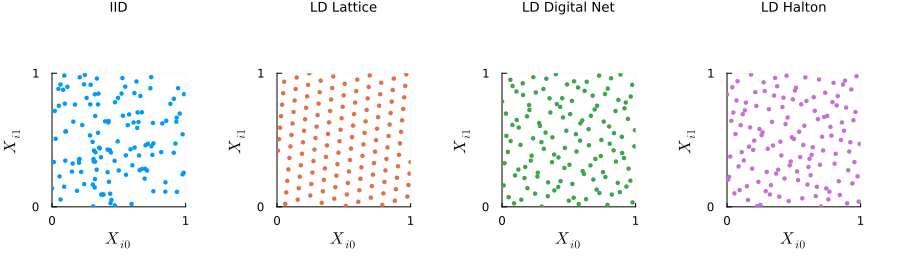

In [4]:
n = 2^7
point_data = [
    ("IID",         IIDStdUniform(2; seed=7)),
    ("LD Lattice",  Lattice(2; seed=7)),
    ("LD Digital Net", DigitalNetB2(2; seed=7, t=63)),
    ("LD Halton",   Halton(2; seed=7, randomize=true)),
]

if HAVE_PLOTS
    ps = []
    for (i, (name, dd)) in enumerate(point_data)
        local x = gen_samples(dd, n)
        local p = scatter(x[:, 1], x[:, 2];
            title=name, xlabel="\$X_{i0}\$", ylabel="\$X_{i1}\$",
            xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
            xticks=[0,1], yticks=[0,1],
            markersize=2.5, markerstrokewidth=0, color=i, label=nothing, size=(250, 280))
        push!(ps, p)
    end
    display(plot(ps...; layout=(1, 4), size=(900, 280), bottom_margin=5Plots.mm))
else
    for (name, dd) in point_data
        local x = gen_samples(dd, n)
        @printf("  %-16s  mean=(%.4f, %.4f)\n", name, mean(x[:, 1]), mean(x[:, 2]))
    end
end

### LD Space-Filling Extensibility

LD sequences are **extensible**: new points fill in the gaps left by previous batches. Here we colour each successive batch of $2^m$ points differently.

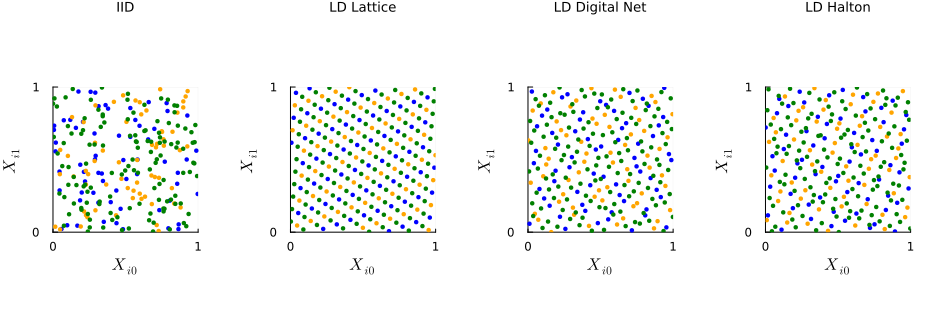

In [5]:
m_min, m_max = 6, 8

if HAVE_PLOTS
    batch_colors = [:blue, :orange, :green]
    ps = []
    for (name, dd) in point_data
        local x = gen_samples(dd, 2^m_max)
        local p = scatter(; title=name, xlabel="\$X_{i0}\$", ylabel="\$X_{i1}\$",
            xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
            xticks=[0,1], yticks=[0,1], legend=false, size=(250, 300))
        n_lo = 0
        for (k, m) in enumerate(m_min:m_max)
            n_hi = 2^m
            scatter!(p, x[n_lo+1:n_hi, 1], x[n_lo+1:n_hi, 2];
                color=batch_colors[k], markersize=2.5, markerstrokewidth=0,
                label=nothing)
            n_lo = n_hi
        end
        push!(ps, p)
    end
    display(plot(ps...; layout=(1, 4), size=(950, 320), bottom_margin=5Plots.mm))
else
    for (name, dd) in point_data
        local x = gen_samples(dd, 2^m_max)
        println("$name: total $(2^m_max) points, batches:")
        n_lo = 0
        for m in m_min:m_max
            n_hi = 2^m
            batch = x[n_lo+1:n_hi, :]
            @printf("  n=%d→%d  mean=(%.4f, %.4f)\n", n_lo, n_hi, mean(batch[:,1]), mean(batch[:,2]))
            n_lo = n_hi
        end
    end
end

### Pair Plots (High-Dimensional Projection)

All $\binom{d}{2}$ 2D projections of a $d=4$ digital net, showing its multi-dimensional coverage.

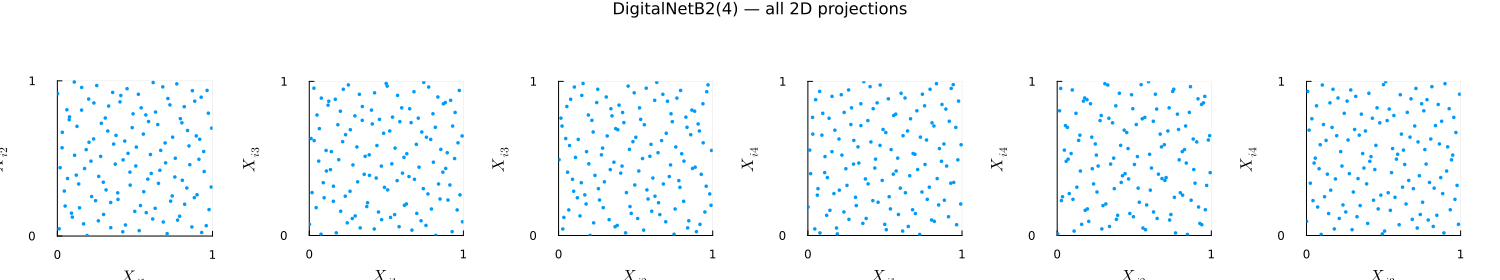

In [6]:
dd4 = DigitalNetB2(4; seed=7, t=63)
x4  = gen_samples(dd4, 2^7)
d4  = 4

if HAVE_PLOTS
    pairs = [(i,j) for i in 1:d4 for j in 1:(i-1)]  # lower-triangle pairs
    ps4 = [
        scatter(x4[:, j], x4[:, i];
            xlabel="\$X_{i$(j)}\$", ylabel="\$X_{i$(i)}\$",
            xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
            xticks=[0,1], yticks=[0,1],
            markersize=2, markerstrokewidth=0, label=nothing)
        for (i,j) in pairs
    ]
    display(plot(ps4...; layout=(1, length(pairs)), size=(length(pairs)*250, 280),
        plot_titlevspan=0.12, plot_title="DigitalNetB2(4) — all 2D projections",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
else
    println("DigitalNetB2(4) projection means:")
    for i in 1:d4, j in 1:(i-1)
        @printf("  (dim%d, dim%d): mean=(%.4f, %.4f)\n", j, i, mean(x4[:,j]), mean(x4[:,i]))
    end
end

## True Measure

The true measure defines the probability distribution $T$ on $\mathcal{T}$ and provides the transform $f(X) = g(\Phi(X))$.

### Gaussian

In [7]:
dd = Halton(3; seed=7)
tm = Gaussian(dd; mean=[1.0, 2.0, 3.0], covariance=[4.0, 5.0, 6.0])  # diagonal covariance

println("4 samples from Gaussian(mean=[1,2,3], diag_cov=[4,5,6]):")
x = gen_samples(dd, 4)
t = transform(tm, x)  # Gaussian samples
for i in 1:4
    @printf("  [%6.3f  %6.3f  %6.3f]\n", t[i,1], t[i,2], t[i,3])
end

println("\nn_start=2 → 2 more samples (extensible):")
x2 = gen_samples(dd, 2; n_start=2)
t2 = transform(tm, x2)
for i in 1:2
    @printf("  [%6.3f  %6.3f  %6.3f]\n", t2[i,1], t2[i,2], t2[i,3])
end

4 samples from Gaussian(mean=[1,2,3], diag_cov=[4,5,6]):


  [ 1.603   1.907   6.483]
  [-0.555   4.019   2.521]


  [ 2.819  -0.317   4.094]
  [ 0.588   2.535   0.687]

n_start=2 → 2 more samples (extensible):
  [ 0.453   5.288   4.736]
  [ 5.837  -1.904   1.430]


### Some True Measure Samplings

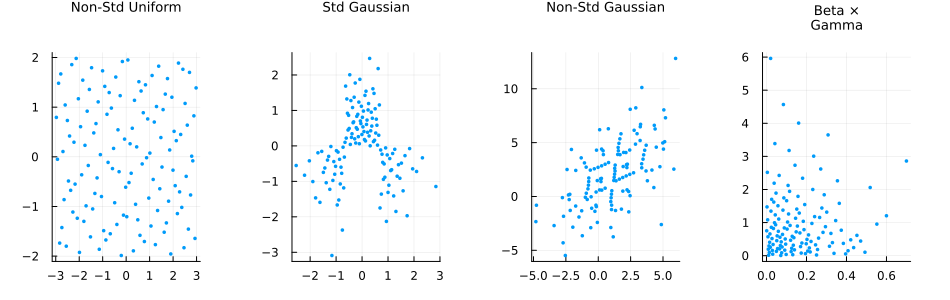

In [8]:
n = 2^7
dd2 = DigitalNetB2(2; seed=7)

true_measures = [
    ("Non-Std Uniform",     Uniform(dd2; lower_bound=[-3,-2], upper_bound=[3,2])),
    ("Std Gaussian",        Gaussian(dd2)),
    ("Non-Std Gaussian",    Gaussian(dd2; mean=[1.0,2.0], covariance=[5.0 4.0; 4.0 9.0])),
    ("Beta ×\nGamma",       DistributionsWrapper(dd2;
                                marginals=Distributions.UnivariateDistribution[
                                    Distributions.Beta(1,5),
                                    Distributions.Gamma(1)])),
]

if HAVE_PLOTS
    ps = []
    for (name, tm_i) in true_measures
        local x = gen_samples(tm_i.dd, n)
        local t = transform(tm_i, x)
        local p = scatter(t[:, 1], t[:, 2];
            title=name, markersize=2, markerstrokewidth=0,
            label=nothing, size=(260, 280))
        push!(ps, p)
    end
    display(plot(ps...; layout=(1, 4), size=(950, 300)))
else
    for (name, tm_i) in true_measures
        local x = gen_samples(tm_i.dd, n)
        local t = transform(tm_i, x)
        @printf("  %-20s  mean=(%.3f, %.3f)\n", replace(name, "\n"=>" "), mean(t[:,1]), mean(t[:,2]))
    end
end

### Brownian Motion Paths

QMC.jl's `BrownianMotion` supports custom drift, diffusion, and initial value.

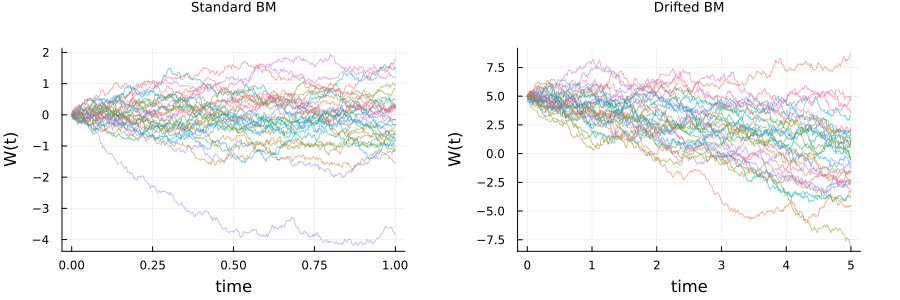

In [9]:
n_paths = 32
dd_bm = Lattice(365; seed=7)

bm_data = [
    ("Standard BM",  BrownianMotion(dd_bm)),
    ("Drifted BM",   BrownianMotion(dd_bm; t_final=5.0, initial_value=5.0, drift=-1.0, diffusion=2.0)),
]

if HAVE_PLOTS
    ps = []
    for (name, bm) in bm_data
        local x = gen_samples(bm.dd, n_paths)
        local t = transform(bm, x)
        tv = [0.0; bm.time_vector]
        local paths = hcat(fill(bm.initial_value, n_paths, 1), t)
        local p = plot(tv, paths'; title=name, xlabel="time", ylabel="W(t)",
            legend=false, alpha=0.5, size=(450, 280))
        push!(ps, p)
    end
    display(plot(ps...; layout=(1, 2), size=(900, 300)))
else
    for (name, bm) in bm_data
        local x = gen_samples(bm.dd, n_paths)
        local t = transform(bm, x)
        @printf("%s: path mean at t_final = %.4f\n", name, mean(t[:, end]))
    end
end

## Integrands

### Wrap Your Own Function

Simple example: $g(T) = T_1 + \cdots + T_d$, $T \sim \mathcal{N}(0, I_d)$, so $\mathbb{E}[g(T)] = 0$.

In [10]:
tm_g = Gaussian(Halton(5; seed=7))
myfun = CustomFun(tm_g, t -> dropdims(sum(t; dims=2); dims=2))

# Manually compute the QMC approximation
x_uniform = gen_samples(tm_g.dd, 2^16)
t_samples  = transform(tm_g, x_uniform)
mu_hat = mean(evaluate(myfun, t_samples))
@printf("QMC approx of E[T₁+…+T₅] ≈ %.2e  (exact = 0)\n", mu_hat)

QMC approx of E[T₁+…+T₅] ≈ -2.21e-04  (exact = 0)


### Arithmetic Asian Option

Geometric Brownian Motion with 52 monthly monitoring dates, arithmetic average payoff.

In [11]:
dd_ao = DigitalNetB2(52; seed=7)
tm_ao = BrownianMotion(dd_ao)  # 52 monthly dates on [0, 1]
asian = FinancialOption(tm_ao;
    option_type   = :asian,
    mean_type     = :arithmetic,
    volatility    = 0.5,
    start_price   = 30.0,
    strike_price  = 35.0,
    interest_rate = 0.001,
)

x_ao = gen_samples(dd_ao, 2^16)
t_ao = transform(tm_ao, x_ao)
mu_ao = mean(evaluate(asian, t_ao))
@printf("Arithmetic Asian option price ≈ %.4f\n", mu_ao)

Arithmetic Asian option price ≈ 1.8334


### Visualising the $f$ vs $g$ Transformation

The Keister integrand is $f(\mathbf{x}) = \pi^{d/2}\cos(\|\mathbf{x}\|)$ over $\mathcal{N}(0, I/2)$. Plotting it against the uniform input $X$ (right) vs the Gaussian sample $T$ (left) illustrates what the change-of-variables does to the integrand.

Keister(1) sample mean (n=32) ≈ 1.3873  (exact = 1.3804)


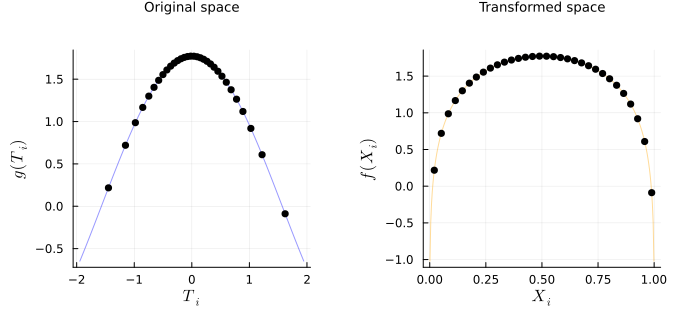

In [12]:
n_k = 32
dd_k  = DigitalNetB2(1; seed=7)
tm_k  = Gaussian(dd_k; covariance=0.5)
keis  = Keister(tm_k)

x_k = gen_samples(dd_k, n_k)
t_k = transform(tm_k, x_k)
f_k = evaluate(keis, t_k)

@printf("Keister(1) sample mean (n=%d) ≈ %.4f  (exact = %.4f)\n",
    n_k, mean(f_k), keister_exact(1))

if HAVE_PLOTS
    # Dense curves for the background
    x_fine = reshape(range(0.001, 0.999; length=300), :, 1)
    t_fine = transform(tm_k, collect(x_fine))
    f_fine = evaluate(keis, t_fine)
    lb = 1.2 * maximum(abs.(t_k))
    t_axis = reshape(range(-lb, lb; length=300), :, 1)
    f_t_axis = evaluate(keis, collect(t_axis))

    p1 = plot(vec(t_axis), f_t_axis; color=:blue, alpha=0.4,
        xlabel="\$T_i\$", ylabel="\$g(T_i)\$", title="Original space", label=nothing)
    scatter!(p1, vec(t_k), f_k; color=:black, markersize=4, label=nothing)

    p2 = plot(vec(x_fine), f_fine; color=:orange, alpha=0.4,
        xlabel="\$X_i\$", ylabel="\$f(X_i)\$", title="Transformed space", label=nothing)
    scatter!(p2, vec(x_k), f_k; color=:black, markersize=4, label=nothing)

    display(plot(p1, p2; layout=(1, 2), size=(700, 320)))
else
    @printf("f values at first 4 uniform points: %s\n",
        join([@sprintf("%.4f", v) for v in f_k[1:4]], "  "))
end

## Stopping Criteria

Adaptively increase $n$ until $|\mu - \hat{\mu}| < \varepsilon$.

### IID CMC vs LD QMC

In [13]:
function make_asian_iid()
    tm = BrownianMotion(IIDStdUniform(52))
    return FinancialOption(tm; option_type=:asian, mean_type=:arithmetic,
        volatility=0.5, start_price=30.0, strike_price=35.0, interest_rate=0.0)
end

function make_asian_qmc()
    tm = BrownianMotion(DigitalNetB2(52; graycode=false))
    return FinancialOption(tm; option_type=:asian, mean_type=:arithmetic,
        volatility=0.5, start_price=30.0, strike_price=35.0, interest_rate=0.0)
end

abs_tol = 0.025

sc_cmc = CubMCG(make_asian_iid(); abs_tol=abs_tol)
r_cmc  = integrate(sc_cmc)
@printf("CMC (CubMCG):      solution = %.4f,  n = %d\n",
    r_cmc.solution, r_cmc.data[:n_total])

sc_qmc = CubQMCNetG(make_asian_qmc(); abs_tol=abs_tol)
r_qmc  = integrate(sc_qmc)
@printf("QMC (CubQMCNetG):  solution = %.4f,  n = %d\n",
    r_qmc.solution, r_qmc.data[:n_total])

@printf("\nQMC used %.1f%% the samples of CMC at ε = %.3f\n",
    100 * r_qmc.data[:n_total] / r_cmc.data[:n_total], abs_tol)

CMC (CubMCG):      solution = 1.8267,  n = 498048
QMC (CubQMCNetG):  solution = 1.8430,  n = 1024



QMC used 0.2% the samples of CMC at ε = 0.025


### Sample Complexity vs Tolerance

CMC scales as $\mathcal{O}(\varepsilon^{-2})$ while QMC achieves $\mathcal{O}(\varepsilon^{-1})$.

Tolerance   CMC (n)      QMC (n)


----------------------------------------
  1.000         2365
  0.750         2885
  0.500         5195
  0.250        11284
  0.100        47957
  0.075        75540
  0.050       130194
  0.025       418967
  ---
  1.000                    1024
  0.500                    1024
  0.100                    1024
  0.050                    1024
  0.020                    2048
  0.010                    4096
  0.005                    8192
  0.002                   16384
  0.001                   65536


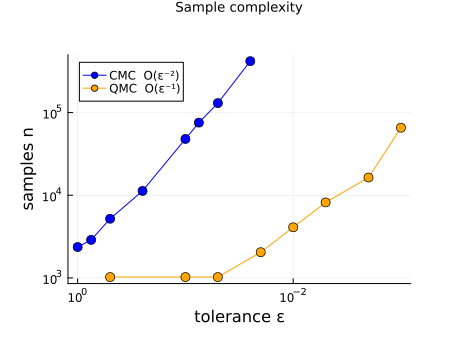

In [14]:
import Logging

cmc_tols = [1.0, 0.75, 0.5, 0.25, 0.1, 0.075, 0.05, 0.025]
qmc_tols = [1.0, 0.5,  0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]

n_cmc = zeros(Int, length(cmc_tols))
for (i, ε) in enumerate(cmc_tols)
    local sc = CubMCG(make_asian_iid(); abs_tol=ε)
    r = Logging.with_logger(Logging.NullLogger()) do
        integrate(sc)
    end
    n_cmc[i] = r.data[:n_total]
end

n_qmc = zeros(Int, length(qmc_tols))
for (i, ε) in enumerate(qmc_tols)
    local sc = CubQMCNetG(make_asian_qmc(); abs_tol=ε)
    r = integrate(sc)
    n_qmc[i] = r.data[:n_total]
end

println("Tolerance   CMC (n)      QMC (n)")
println("-"^40)
for (ε, n) in zip(cmc_tols, n_cmc)
    @printf("  %.3f     %8d\n", ε, n)
end
println("  ---")
for (ε, n) in zip(qmc_tols, n_qmc)
    @printf("  %.3f                %8d\n", ε, n)
end

if HAVE_PLOTS
    p1 = plot(; xlabel="tolerance ε", ylabel="samples n",
        xscale=:log10, yscale=:log10, xflip=true,
        title="Sample complexity", size=(450, 350), legend=:topleft)
    plot!(p1, cmc_tols, n_cmc; marker=:circle, markersize=5,
        label="CMC  O(ε⁻²)", color=:blue)
    plot!(p1, qmc_tols[2:end], n_qmc[2:end]; marker=:circle, markersize=5,
        label="QMC  O(ε⁻¹)", color=:orange)
    display(p1)
end

## Vector Functions of Integrals

QMC.jl can estimate several integrals simultaneously using **replicated** point sets. More examples: [`demos/vectorized_qmc.ipynb`](../../vectorized_qmc.ipynb) and [`demos/vectorized_qmc_bayes.ipynb`](../../vectorized_qmc_bayes.ipynb).

### Two Simultaneous Integrals via Replications

Compute $\mathbb{E}_{T\sim\mathcal{U}[0,\pi]^3}[\cos(T_1)\cos(T_2)\cos(T_3)]$ and $\mathbb{E}[\sin(T_1)\sin(T_2)\sin(T_3)]$ simultaneously.

Exact values: $$\frac{1}{\pi^3}\int_0^{\pi}\int_0^{\pi}\int_0^{\pi}\cos(t_1)\cos(t_2)\cos(t_3)\,\mathrm{d}t = 0, \quad \frac{1}{\pi^3}\int_0^{\pi}\int_0^{\pi}\int_0^{\pi}\sin(t_1)\sin(t_2)\sin(t_3)\,\mathrm{d}t = \left(\frac{2}{\pi}\right)^3 \approx 0.2583$$

In [15]:
R = 32  # replications for Student-t CI across randomizations
dd_v = Halton(3; seed=7, replications=R)
tm_v = Uniform(dd_v; lower_bound=0.0, upper_bound=π)

cos_fun = CustomFun(tm_v, t -> dropdims(prod(cos.(t); dims=2); dims=2))
sin_fun = CustomFun(tm_v, t -> dropdims(prod(sin.(t); dims=2); dims=2))

r_cos = integrate(CubQMCRepStudentT(cos_fun; abs_tol=1e-4, n_init=2^8))
r_sin = integrate(CubQMCRepStudentT(sin_fun; abs_tol=1e-4, n_init=2^8))

@printf("∫cos(t1)cos(t2)cos(t3)dt / π³ ≈ %+.2e  (exact = 0)\n", r_cos.solution)
@printf("∫sin(t1)sin(t2)sin(t3)dt / π³ ≈  %.6f  (exact = %.6f)\n",
    r_sin.solution, (2/π)^3)

∫cos(t1)cos(t2)cos(t3)dt / π³ ≈ +2.16e-05  (exact = 0)
∫sin(t1)sin(t2)sin(t3)dt / π³ ≈  0.258038  (exact = 0.258012)


### Covariance Estimation

Let $T \sim \mathcal{N}(1, I_d)$, $P = \prod_{j=1}^d T_j$, $S = \sum_{j=1}^d T_j$. Then $$\mathrm{Cov}[P, S] = \mathbb{E}[PS] - \mathbb{E}[P]\mathbb{E}[S] = d,$$ since $\mathrm{Var}[T_j]=1$, $\mathbb{E}[T_j]=1$, and each $T_j$ contributes $\mathbb{E}[T_j]^{d-1}\,\mathbb{E}[T_j^2] - \mathbb{E}[T_j]^d = 2 - 1 = 1$ to $\mathbb{E}[PS]$, while $\mathbb{E}[P]\mathbb{E}[S] = 1 \cdot d = d$.

We compute $\mathbb{E}[PS]$, $\mathbb{E}[P]$, $\mathbb{E}[S]$ as three separate integrals, then combine.

In [16]:
d_cov = 10
dd_cov = Lattice(d_cov; seed=7, generating_vector=22)
tm_cov = Gaussian(dd_cov; mean=fill(1.0, d_cov))

PS_fun = CustomFun(tm_cov, t -> begin
    P = dropdims(prod(t; dims=2); dims=2)
    S = dropdims(sum(t; dims=2); dims=2)
    return P .* S
end)

P_fun = CustomFun(tm_cov, t -> dropdims(prod(t; dims=2); dims=2))
S_fun = CustomFun(tm_cov, t -> dropdims(sum(t; dims=2); dims=2))

rel_tol = 0.025

r_PS = integrate(CubQMCLatticeG(PS_fun; rel_tol=rel_tol, abs_tol=0.01))
r_P  = integrate(CubQMCLatticeG(P_fun;  rel_tol=rel_tol, abs_tol=0.01))
r_S  = integrate(CubQMCLatticeG(S_fun;  rel_tol=rel_tol, abs_tol=0.01))

cov_est = r_PS.solution - r_P.solution * r_S.solution
@printf("E[PS] ≈ %.4f,  E[P] ≈ %.4f,  E[S] ≈ %.4f\n",
    r_PS.solution, r_P.solution, r_S.solution)
@printf("Cov[P,S] = E[PS] - E[P]E[S] ≈ %.4f  (exact = %d)\n", cov_est, d_cov)

E[PS] ≈ 20.8256,  E[P] ≈ 0.9204,  E[S] ≈ 9.9911
Cov[P,S] = E[PS] - E[P]E[S] ≈ 11.6299  (exact = 10)


## Sensitivity Indices

For a machine-learning + sensitivity-indices example (fitting a classifier on Iris and computing Sobol' indices over the feature domain), see [`demos/iris.ipynb`](../../iris.ipynb).

Here we show a quick scalar example: the **Ishigami function** in $d=3$, $f(T) = \sin(T_1) + a\sin^2(T_2) + b\,T_3^4\sin(T_1)$, $T\sim\mathcal{U}[-\pi,\pi]^3$. The exact first-order Sobol' indices are known analytically.

In [17]:
a_ish, b_ish = 7.0, 0.1

# Exact closed-form indices for Ishigami (see Saltelli 2010)
V_ish = a_ish^2/8 + b_ish*π^4/5 + b_ish^2*π^8/18 + 1/2
V1    = b_ish*π^4/5 + b_ish^2*π^8/50 + 1/2
V2    = a_ish^2 / 8
V3    = 0.0
S1_exact, S2_exact, S3_exact = V1/V_ish, V2/V_ish, V3/V_ish

dd_ish = DigitalNetB2(6; seed=7)  # 2d = 6, original d = 3
tm_ish = Uniform(dd_ish; lower_bound=fill(-π, 6), upper_bound=fill(π, 6))

# The 3rd argument sets integrand.dimension = 3; SensitivityIndices handles X/Z splitting
ishigami = CustomFun(tm_ish, t -> begin
    @. sin(t[:, 1]) + a_ish * sin(t[:, 2])^2 + b_ish * t[:, 3]^4 * sin(t[:, 1])
end, 3)

si = SensitivityIndices(ishigami)
n_si = 2^14
x_si  = gen_samples(dd_ish, n_si)
t_si  = transform(tm_ish, x_si)
closed_si, total_si = compute_sensitivity_indices(si, t_si)

println("Ishigami function sensitivity indices (d=3):")
println("            S1       S2       S3")
@printf("  QMC:   %.4f   %.4f   %.4f\n", closed_si[1], closed_si[2], closed_si[3])
@printf("  Exact: %.4f   %.4f   %.4f\n", S1_exact, S2_exact, S3_exact)

Ishigami function sensitivity indices (d=3):


            S1       S2       S3
  QMC:   0.3136   0.4424   -0.0000
  Exact: 0.3139   0.4424   0.0000
